In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv(
    'C:/Users/navee/Downloads/student_placement_prediction_dataset_2026.csv'
)

print(df.head())
print(df.columns.tolist())

   student_id  age  gender  cgpa branch college_tier  internships_count  \
0           1   24    Male  7.53     IT       Tier 2                  4   
1           2   21    Male  7.92    CSE       Tier 2                  1   
2           3   22  Female  8.60    EEE       Tier 1                  0   
3           4   24    Male  6.68    CSE       Tier 1                  0   
4           5   20  Female  8.43     IT       Tier 3                  1   

   projects_count  certifications_count  coding_skill_score  ...  \
0               6                     1           99.238568  ...   
1               3                     6           80.966123  ...   
2               1                     1           49.177184  ...   
3               2                     2           79.359084  ...   
4               4                     3           65.018573  ...   

   mock_interview_score  attendance_percentage  backlogs  \
0             72.647009              77.463863         2   
1             61.699

In [62]:
#show datasets info 

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [63]:
#describe dataset 
df.describe()


,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


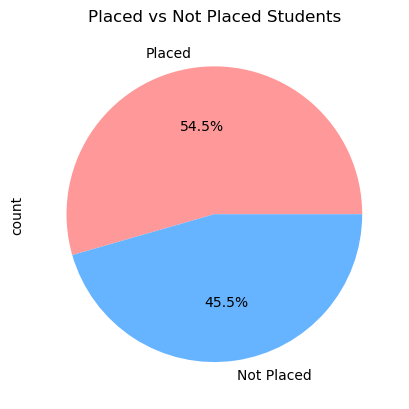

In [64]:
#visualize placed vs not placed students
df['placement_status'].value_counts().plot(kind='pie',autopct='%1.1f%%',colors=['#ff9999','#66b3ff'])
plt.title('Placed vs Not Placed Students')
plt.show()



In [65]:
df

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,...,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,...,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,...,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,...,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00


In [66]:
df.drop('college_tier' , axis=1 , inplace=True)

print(df.columns.tolist())

['student_id', 'age', 'gender', 'cgpa', 'branch', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status', 'salary_package_lpa']


In [67]:
#data cleaning and preprocessing
df.drop(['coding_skill_score','aptitude_score',
'logical_reasoning_score',
'aptitude_score',
'communication_skill_score'], axis=1, inplace=True)

In [68]:
df

,student_id,age,gender,cgpa,branch,internships_count,projects_count,certifications_count,hackathons_participated,github_repos,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,4,6,1,4,1,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,1,3,6,0,2,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,0,1,1,0,2,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,0,2,2,1,1,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,1,4,3,1,4,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,21,Male,7.97,Mechanical,0,3,5,0,5,...,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,1,1,2,0,2,...,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,2,4,4,0,6,...,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,2,3,0,0,6,...,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00


In [ ]:
df=df.drop(columns=["coding_skill_score", "aptitude_score", "communication_skill_score", "logical_reasoning_score", "hackathons_participated", "github_repos", "linkedin_connections", "mock_interview_score", "attendance_percentage", "backlogs", "extracurricular_score", "leadership_score", "volunteer_experience", "sleep_hours", "study_hours_per_day", "social_media_usage", "part_time_job", "internship_experience", "certifications", "online_courses_completed", "teamwork_score", "problem_solving_score", "creativity_score", "adaptability_score", "time_management_score", "stress_management_score", "emotional_intelligence_score", "self_motivation_score", "goal_setting_score", "decision_making_score"],errors='ignore')

In [70]:
df

,student_id,age,gender,cgpa,branch,internships_count,projects_count,certifications_count,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,4,6,1,Not Placed,0.00
1,2,21,Male,7.92,CSE,1,3,6,Not Placed,0.00
2,3,22,Female,8.60,EEE,0,1,1,Placed,11.99
3,4,24,Male,6.68,CSE,0,2,2,Not Placed,0.00
4,5,20,Female,8.43,IT,1,4,3,Placed,12.16
...,...,...,...,...,...,...,...,...,...,...
99995,99996,21,Male,7.97,Mechanical,0,3,5,Placed,14.54
99996,99997,18,Female,7.79,CSE,1,1,2,Not Placed,0.00
99997,99998,20,Female,6.71,IT,2,4,4,Placed,13.45
99998,99999,19,Female,7.21,CSE,2,3,0,Not Placed,0.00


In [71]:
df.isnull().sum()

student_id              0
age                     0
gender                  0
cgpa                    0
branch                  0
internships_count       0
projects_count          0
certifications_count    0
placement_status        0
salary_package_lpa      0
dtype: int64

In [72]:
print("Gender:")
print(df['gender'].unique())

print("\nBranch:")
print(df['branch'].unique())

print("\nprojects_count:")
print(df['projects_count'].unique())

print("\nPlacement Status:")
print(df['placement_status'].unique())

Gender:
['Male' 'Female']

Branch:
['IT' 'CSE' 'EEE' 'Civil' 'Mechanical' 'ECE']

projects_count:
[ 6  3  1  2  4  5  0  7  8 10  9 11 12 13]

Placement Status:
['Not Placed' 'Placed']


In [73]:
#change into numerical data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = [
    'gender',
    'branch',
    'placement_status'
]

encoders = {}

for col in cat_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = le

print(encoders)

{'gender': LabelEncoder(), 'branch': LabelEncoder(), 'placement_status': LabelEncoder()}


In [74]:
df

,student_id,age,gender,cgpa,branch,internships_count,projects_count,certifications_count,placement_status,salary_package_lpa
0,1,24,1,7.53,4,4,6,1,0,0.00
1,2,21,1,7.92,0,1,3,6,0,0.00
2,3,22,0,8.60,3,0,1,1,1,11.99
3,4,24,1,6.68,0,0,2,2,0,0.00
4,5,20,0,8.43,4,1,4,3,1,12.16
...,...,...,...,...,...,...,...,...,...,...
99995,99996,21,1,7.97,5,0,3,5,1,14.54
99996,99997,18,0,7.79,0,1,1,2,0,0.00
99997,99998,20,0,6.71,4,2,4,4,1,13.45
99998,99999,19,0,7.21,0,2,3,0,0,0.00


In [75]:
target_encoder = LabelEncoder()

df['placement_status'] = target_encoder.fit_transform(
    df['placement_status'].astype(str)
)

print(target_encoder.classes_)

['0' '1']


In [76]:
#scale Numerical colums 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['age','cgpa','internships_count','projects_count','certifications_count']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [77]:
df.to_csv('C:/Users/navee/Downloads/student_placement_prediction_dataset_2026_cleaned.csv', index=False)

In [78]:
#model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


#load preproceesed data
df = pd.read_csv('C:/Users/navee/Downloads/student_placement_prediction_dataset_2026_cleaned.csv')

In [89]:
X = df.drop(['placement_status', 'salary_package_lpa', 'student_id'], axis=1)
Y = df['placement_status']

print("X columns:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("Y shape:", Y.shape)

X columns:
['age', 'gender', 'cgpa', 'branch', 'internships_count', 'projects_count', 'certifications_count']

X shape: (100000, 7)
Y shape: (100000,)


In [90]:
#train test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

#Model Training
model = RandomForestClassifier(
    random_state=42
)
model.fit(X_train, Y_train)

#Prediction
Y_pred = model.predict(X_test)

#Evaluation
print("Accuracy Score:", accuracy_score(Y_test, Y_pred))

print("confusion_matrix:\n", confusion_matrix(Y_test, Y_pred))
print ("Classification Report:\n", classification_report(Y_test, Y_pred))

Accuracy Score: 0.5205
confusion_matrix:
 [[3897 5230]
 [4360 6513]]
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.43      0.45      9127
           1       0.55      0.60      0.58     10873

    accuracy                           0.52     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.52      0.52      0.52     20000



In [91]:
with open("placement_predict.pkl", "wb") as f:
    pickle.dump(model, f)

In [92]:
with open("labelencoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [93]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [94]:
with open("target_encoder.pkl", "wb") as f:
    pickle.dump(target_encoder, f)

In [95]:
print(model.feature_names_in_.tolist())

['age', 'gender', 'cgpa', 'branch', 'internships_count', 'projects_count', 'certifications_count']
